# 🍽️ Food Image Classifier — Training Notebook
### Transfer Learning with MobileNetV2 (TensorFlow/Keras)

This notebook trains a food image classifier on **15 food classes** using transfer learning.

**Pipeline:**
1. Load & augment dataset
2. Build model on top of pretrained MobileNetV2
3. Train classification head
4. Fine-tune top layers
5. Evaluate (accuracy, confusion matrix, classification report)
6. Export model + class labels for the Streamlit app

> Run this on **Google Colab** with GPU: `Runtime > Change runtime type > GPU`


## 1. Setup & Upload Dataset
Upload your `food_img_data_resized.zip` when prompted (or place it in your Drive and adjust the path).

In [ ]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Upload the dataset zip (Colab file upload)
from google.colab import files
uploaded = files.upload()  # select food_img_data_resized.zip
zip_name = list(uploaded.keys())[0]
print("Uploaded:", zip_name)

Saving food_img_data_resized.zip to food_img_data_resized.zip
Uploaded: food_img_data_resized.zip


In [ ]:
import zipfile, os

extract_path = "/content/dataset"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Find the actual folder containing class subfolders
for root, dirs, files_ in os.walk(extract_path):
    if len(dirs) >= 10:   # the folder with all 15 class subfolders
        DATA_DIR = root
        break

print("Data directory:", DATA_DIR)
print("Classes found:", sorted(os.listdir(DATA_DIR)))

Data directory: /content/dataset/food_img_data_resized
Classes found: ['Pavbhaji', 'biryani', 'burger', 'dosa', 'french fries', 'fruits_salad', 'idli', 'noodles', 'paneer_tikka', 'pasta', 'pizza', 'samosa', 'sandwiches', 'sushi', 'vegetable_salad']


## 2. Explore Dataset

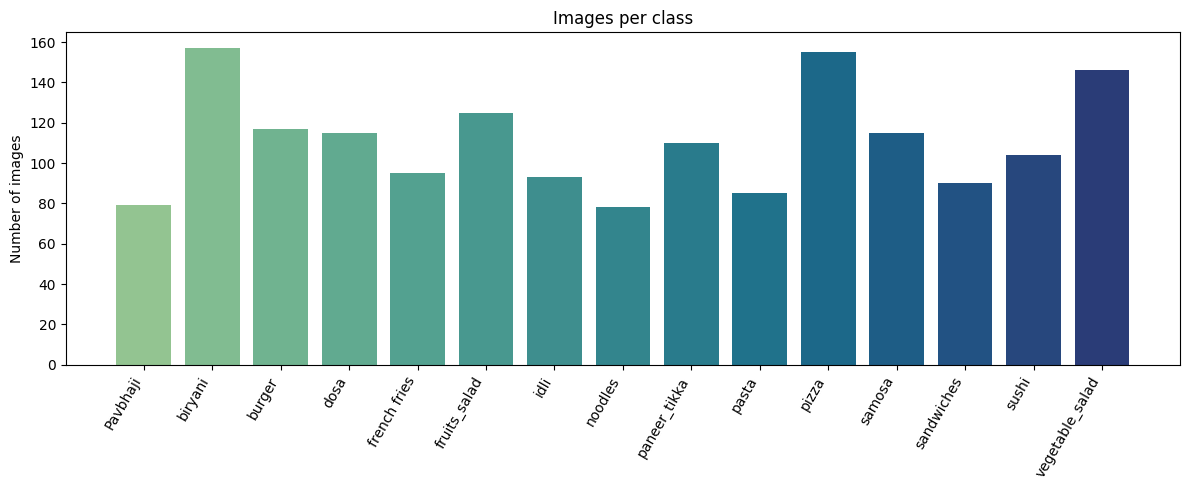

{'Pavbhaji': 79, 'biryani': 157, 'burger': 117, 'dosa': 115, 'french fries': 95, 'fruits_salad': 125, 'idli': 93, 'noodles': 78, 'paneer_tikka': 110, 'pasta': 85, 'pizza': 155, 'samosa': 115, 'sandwiches': 90, 'sushi': 104, 'vegetable_salad': 146}
Total images: 1664


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

class_names = sorted(os.listdir(DATA_DIR))
counts = {c: len(os.listdir(os.path.join(DATA_DIR, c))) for c in class_names}

plt.figure(figsize=(12,5))

# Crest color palette
colors = sns.color_palette("crest", n_colors=len(class_names))

plt.bar(counts.keys(), counts.values(), color=colors)

plt.xticks(rotation=60, ha='right')
plt.ylabel("Number of images")
plt.title("Images per class")

plt.tight_layout()
plt.show()

print(counts)
print("Total images:", sum(counts.values()))

## 3. Data Generators (with Augmentation)

Since we have a modest dataset (~1600 images / 15 classes), augmentation is important to reduce overfitting:
- rotation, zoom, shift, horizontal flip, brightness variation


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

NUM_CLASSES = train_gen.num_classes
class_indices = train_gen.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
print("Class mapping:", class_indices)

Found 1335 images belonging to 15 classes.
Found 329 images belonging to 15 classes.
Class mapping: {'Pavbhaji': 0, 'biryani': 1, 'burger': 2, 'dosa': 3, 'french fries': 4, 'fruits_salad': 5, 'idli': 6, 'noodles': 7, 'paneer_tikka': 8, 'pasta': 9, 'pizza': 10, 'samosa': 11, 'sandwiches': 12, 'sushi': 13, 'vegetable_salad': 14}


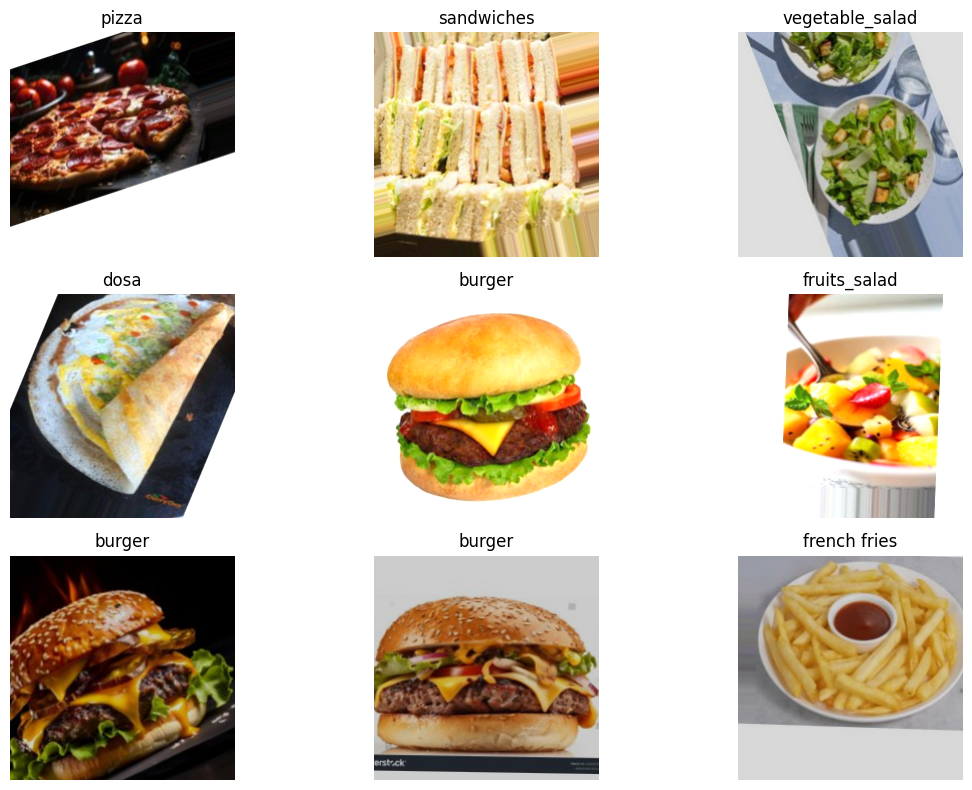

In [ ]:
# Visualize a batch of augmented training images
imgs, labels = next(train_gen)

plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(imgs[i])
    label_idx = labels[i].argmax()
    plt.title(idx_to_class[label_idx])
    plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Build Model — MobileNetV2 Transfer Learning

- Base: MobileNetV2 pretrained on ImageNet, **frozen** initially
- Custom head: GlobalAveragePooling → Dense(128, relu) → Dropout(0.3) → Dense(15, softmax)


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze base for stage 1

inputs = layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,424,399 (9.25 MB)

 Trainable params: 166,159 (649.06 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

## 5. Stage 1 — Train the Classification Head
Base model stays frozen. We only train the new head layers.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

EPOCHS_STAGE1 = 15

history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE1,
    callbacks=callbacks
)

Epoch 1/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.5760 - loss: 1.4818 - val_accuracy: 0.6869 - val_loss: 1.0747 - learning_rate: 0.0010
Epoch 2/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 24s 574ms/step - accuracy: 0.8135 - loss: 0.6236 - val_accuracy: 0.7690 - val_loss: 0.7462 - learning_rate: 0.0010
Epoch 3/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 24s 574ms/step - accuracy: 0.8712 - loss: 0.4462 - val_accuracy: 0.8237 - val_loss: 0.6143 - learning_rate: 0.0010
Epoch 4/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 23s 544ms/step - accuracy: 0.8794 - loss: 0.4000 - val_accuracy: 0.7964 - val_loss: 0.6334 - learning_rate: 0.0010
Epoch 5/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 24s 557ms/step - accuracy: 0.8951 - loss: 0.3410 - val_accuracy: 0.8116 - val_loss: 0.5827 - learning_rate: 0.0010
Epoch 6/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 25s 611ms/step - accuracy: 0.9236 - loss: 0.2656 - val_accuracy: 0.8359 - val_loss: 0.5306 - learning_rate: 0.0010
Epoch 7/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 24s 580ms/step - accuracy: 0.9243 - loss: 0.262

## 6. Stage 2 — Fine-Tuning
Unfreeze the top layers of MobileNetV2 and train with a very low learning rate. This lets the network adapt its higher-level features specifically to food images, usually giving a solid accuracy boost.


In [ ]:
base_model.trainable = True

# Unfreeze fewer layers (last 20 instead of 40) — less risk of overfitting
fine_tune_at = len(base_model.layers) - 20
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),  # lower LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Fresh callbacks for stage 2 (important: don't reuse stage 1's callback objects)
callbacks_stage2 = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7)
]

EPOCHS_STAGE2 = 10

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE2,
    callbacks=callbacks_stage2
)

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.8517 - loss: 0.4287 - val_accuracy: 0.8146 - val_loss: 0.6894 - learning_rate: 5.0000e-06
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 23s 554ms/step - accuracy: 0.8734 - loss: 0.4125 - val_accuracy: 0.8176 - val_loss: 0.6369 - learning_rate: 5.0000e-06
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 23s 554ms/step - accuracy: 0.8989 - loss: 0.3573 - val_accuracy: 0.8024 - val_loss: 0.6917 - learning_rate: 5.0000e-06
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 23s 556ms/step - accuracy: 0.8929 - loss: 0.3445 - val_accuracy: 0.7994 - val_loss: 0.7333 - learning_rate: 5.0000e-06
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 23s 546ms/step - accuracy: 0.8936 - loss: 0.3638 - val_accuracy: 0.8116 - val_loss: 0.7465 - learning_rate: 2.5000e-06
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 22s 523ms/step - accuracy: 0.8921 - loss: 0.3535 - val_accuracy: 0.8055 - val_loss: 0.7866 - learning_rate: 2.5000e-06


## 7. Training Curves

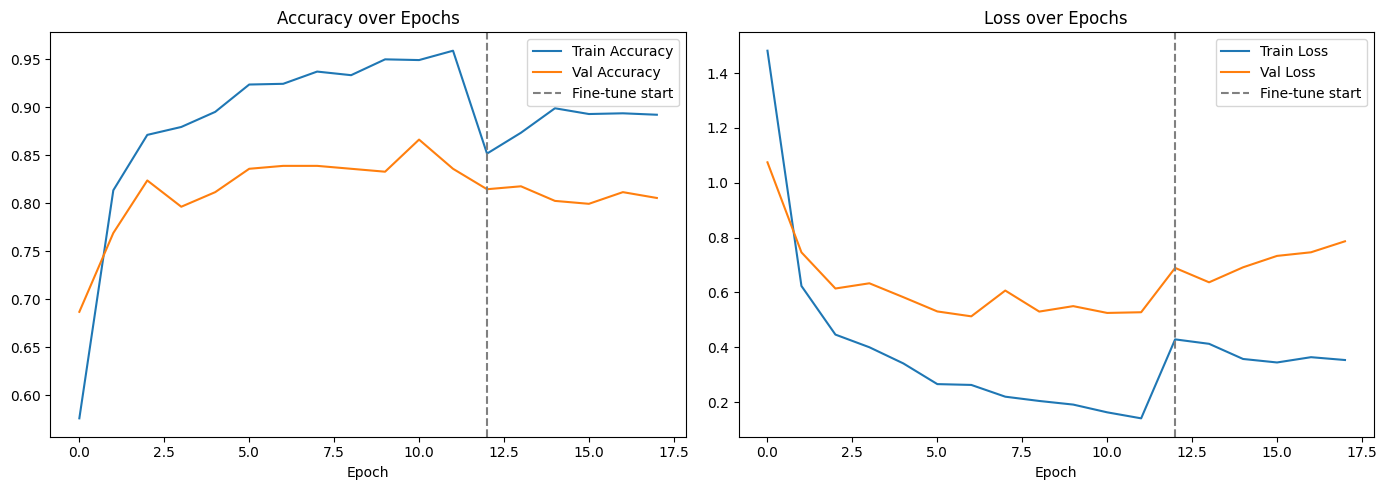

Final Validation Accuracy: 80.55%


In [ ]:
def combine_history(h1, h2, key):
    return h1.history[key] + h2.history[key]

acc = combine_history(history1, history2, 'accuracy')
val_acc = combine_history(history1, history2, 'val_accuracy')
loss = combine_history(history1, history2, 'loss')
val_loss = combine_history(history1, history2, 'val_loss')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(acc, label='Train Accuracy')
axes[0].plot(val_acc, label='Val Accuracy')
axes[0].axvline(x=len(history1.history['accuracy']), color='gray', linestyle='--', label='Fine-tune start')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(loss, label='Train Loss')
axes[1].plot(val_loss, label='Val Loss')
axes[1].axvline(x=len(history1.history['loss']), color='gray', linestyle='--', label='Fine-tune start')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

print(f"Final Validation Accuracy: {val_acc[-1]*100:.2f}%")

## 8. Evaluation — Confusion Matrix & Classification Report

11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 564ms/step


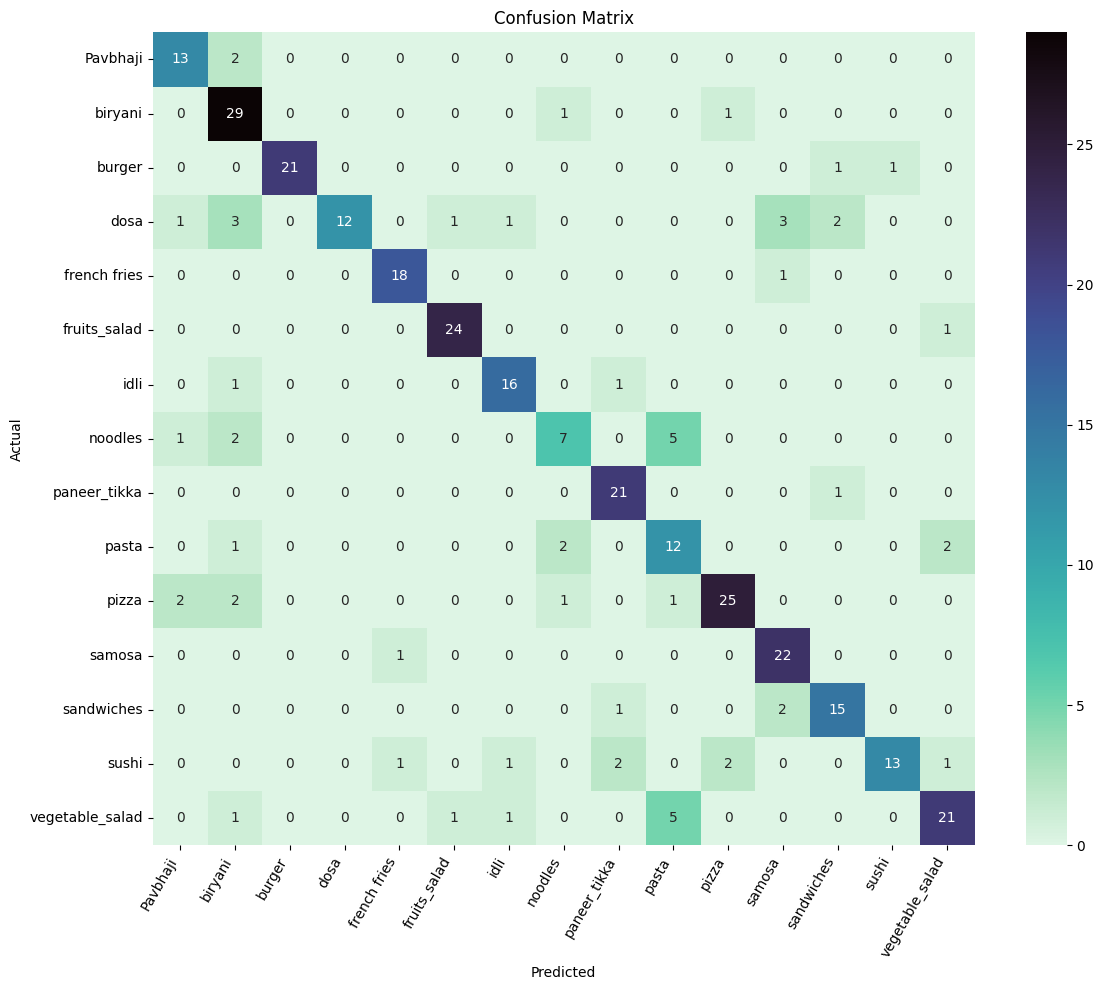

                 precision    recall  f1-score   support

       Pavbhaji       0.76      0.87      0.81        15
        biryani       0.71      0.94      0.81        31
         burger       1.00      0.91      0.95        23
           dosa       1.00      0.52      0.69        23
   french fries       0.90      0.95      0.92        19
   fruits_salad       0.92      0.96      0.94        25
           idli       0.84      0.89      0.86        18
        noodles       0.64      0.47      0.54        15
   paneer_tikka       0.84      0.95      0.89        22
          pasta       0.52      0.71      0.60        17
          pizza       0.89      0.81      0.85        31
         samosa       0.79      0.96      0.86        23
     sandwiches       0.79      0.83      0.81        18
          sushi       0.93      0.65      0.76        20
vegetable_salad       0.84      0.72      0.78        29

       accuracy                           0.82       329
      macro avg       0.82   

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

val_gen.reset()
y_pred_probs = model.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes

class_labels = [idx_to_class[i] for i in range(NUM_CLASSES)]

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='mako_r', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_true, y_pred, target_names=class_labels))

## 9. Export Model + Class Labels

Save everything needed for the Streamlit app:
- `food_classifier_model.h5` — the trained model
- `class_labels.json` — index → class name mapping


In [ ]:
import json

model.save('food_classifier_model.h5')

with open('class_labels.json', 'w') as f:
    json.dump(idx_to_class, f, indent=2)

print("Saved: food_classifier_model.h5")
print("Saved: class_labels.json")
print(idx_to_class)

Saved: food_classifier_model.h5
Saved: class_labels.json
{0: 'Pavbhaji', 1: 'biryani', 2: 'burger', 3: 'dosa', 4: 'french fries', 5: 'fruits_salad', 6: 'idli', 7: 'noodles', 8: 'paneer_tikka', 9: 'pasta', 10: 'pizza', 11: 'samosa', 12: 'sandwiches', 13: 'sushi', 14: 'vegetable_salad'}


In [ ]:
# Download to your machine (to add to your Streamlit app repo)
from google.colab import files
files.download('food_classifier_model.h5')
files.download('class_labels.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Quick Test — Predict on a Single Image


In [ ]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_image(img_path, model, idx_to_class, top_k=3):
    img = keras_image.load_img(img_path, target_size=(224, 224))
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)[0]
    top_indices = preds.argsort()[-top_k:][::-1]

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {idx_to_class[top_indices[0]]} ({preds[top_indices[0]]*100:.1f}%)")
    plt.show()

    print("Top predictions:")
    for i in top_indices:
        print(f"  {idx_to_class[i]}: {preds[i]*100:.2f}%")

# Example usage (upload a test image and update the path):
# predict_image('/content/test_food.jpg', model, idx_to_class)